In [85]:
import importlib
import smw_setup
importlib.reload(smw_setup)
from smw_setup import *
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 3060 Ti


#### PPO Algorithm

In [86]:
try:
    base_env.close()
except:
    pass

In [87]:
# base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode='human')
base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode='none')
env = SMWEnv(base_env)

total_rewards = []
steps_per_ep  = []
max_x_per_ep  = []
actor_losses  = []
critic_losses = []

In [88]:
class SMW_PPO:
    def __init__(self, env, action_dim, theta, epsilon=0.2, alpha=0.95, gamma=0.99, num_steps=4096):
        self.env = env
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.num_steps = num_steps
        self.num_eps = 2000

        # Trajectory buffer
        self.states    = []
        self.actions   = []
        self.rewards   = []
        self.log_probs = []
        self.values    = []
        self.dones     = []
        self.xs        = []  # track x position for logging
        self.theta = theta

        self.state, _ = self.env.reset()
        self.states = np.zeros((num_steps, 84, 84, NUM_STACK), dtype=np.uint8)
        self.step_idx = 0

        # Combined actor-critic model
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = ActorCritic(action_dim=action_dim).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=1e-4)

        self.policy = []

    def collect_trajectories(self):
        for _ in range(self.num_steps):
            state_t = torch.tensor(self.state, dtype=torch.uint8).unsqueeze(0).to(self.device)
            action, log_prob, _, value = self.model(state_t)
            action_idx = action.item()

            next_state, reward, terminated, truncated, info = self.env.step(action_idx)
            done = terminated or truncated

            self.states[self.step_idx] = self.state
            self.step_idx += 1
            self.actions.append(action_idx)
            self.rewards.append(reward)
            self.log_probs.append(log_prob)
            self.values.append(value)
            self.dones.append(done)
            self.xs.append(info.get('x', 0))

            if done:
                self.state, _ = self.env.reset()
            else:
                self.state = next_state

        return self.states, self.actions, self.rewards, self.log_probs, self.values, self.dones

    def r_to_go(self):
        Rt = []
        discounted_sum = 0

        for reward, done in zip(reversed(self.rewards), reversed(self.dones)):
            if done:
                discounted_sum = 0
            discounted_sum = reward + self.gamma * discounted_sum
            Rt.insert(0, discounted_sum)

        return Rt

    def advantage_est(self):
        V = torch.stack(self.values).squeeze().detach()
        T = len(self.rewards)
        advantages = []
        next_gae = 0

        for t in reversed(range(T)):
            if self.dones[t]:
                next_value = 0
                next_gae = 0
            else:
                next_value = V[t+1].item() if t+1 < T else 0

            delta = self.rewards[t] + self.gamma * next_value - V[t].item()
            gae = delta + self.gamma * self.alpha * next_gae
            next_gae = gae
            advantages.insert(0, torch.tensor(gae, dtype=torch.float32))

        advantages = torch.stack(advantages)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        return advantages

    def update(self):
        states_t = torch.from_numpy(self.states)  # stay on CPU
        old_logs   = torch.stack(self.log_probs).detach().to(self.device)
        advantages = self.advantage_est().detach().to(self.device)
        returns    = torch.tensor(self.r_to_go(), dtype=torch.float32).to(self.device)

        MINIBATCH = 256
        num_samples = len(self.rewards)

        for _ in range(4):
            # shuffle indices each epoch
            indices = torch.randperm(num_samples)
            for start in range(0, num_samples, MINIBATCH):
                idx = indices[start:start + MINIBATCH]
                
                mb_states = states_t[idx].to(self.device)
                mb_old_logs   = old_logs[idx]
                mb_advantages = advantages[idx]
                mb_returns    = returns[idx]

                _, new_log_probs, dist, new_values = self.model(mb_states)
                new_values = new_values.squeeze()

                ratio = torch.exp(new_log_probs - mb_old_logs)

                unclipped  = ratio * mb_advantages
                clipped    = torch.clamp(ratio, 1 - self.epsilon, 1 + self.epsilon) * mb_advantages

                entropy     = dist.entropy().mean()
                actor_loss  = -torch.mean(torch.min(unclipped, clipped)) - 0.001 * entropy
                critic_loss = nn.MSELoss()(new_values, mb_returns)

                self.optimizer.zero_grad()
                loss = actor_loss + 0.5 * critic_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
                self.optimizer.step()

        return actor_loss.item(), critic_loss.item()

    def clear_buffer(self):
        self.step_idx = 0
        self.actions   = []
        self.rewards   = []
        self.log_probs = []
        self.values    = []
        self.dones     = []
        self.xs        = []

    def rollout(self):
        for ep in range(self.num_eps):
            self.collect_trajectories()

            total_rewards.append(sum(self.rewards))
            steps_per_ep.append(len(self.rewards))
            max_x_per_ep.append(max(self.xs))
            actor_loss, critic_loss = self.update()
            actor_losses.append(actor_loss)
            critic_losses.append(critic_loss)

            self.clear_buffer()
            if (ep + 1) % 50 == 0:
                torch.save(self.model.state_dict(), f'Checkpoints/checkpoint_ep{ep+1}.pth')
            print(f"Episode {ep+1}/{self.num_eps} | Reward: {total_rewards[-1]:.2f} | Max X: {max_x_per_ep[-1]}")

#### Run the agent

In [ ]:
del agent
torch.cuda.empty_cache()
agent = SMW_PPO(env=env, action_dim=env.action_space.n, theta=None)
agent.rollout()

Episode 1/2000 | Reward: 45.54 | Max X: 1563
Episode 2/2000 | Reward: 815.15 | Max X: 4369
Episode 3/2000 | Reward: 24.70 | Max X: 1605
Episode 4/2000 | Reward: 24.16 | Max X: 447
Episode 5/2000 | Reward: 40.75 | Max X: 2202
Episode 6/2000 | Reward: 46.90 | Max X: 1548
Episode 7/2000 | Reward: 33.56 | Max X: 2126
Episode 8/2000 | Reward: 31.45 | Max X: 2114
Episode 9/2000 | Reward: 11.99 | Max X: 483
Episode 10/2000 | Reward: 19.19 | Max X: 1389
Episode 11/2000 | Reward: 41.97 | Max X: 2104
Episode 12/2000 | Reward: 23.83 | Max X: 1538
Episode 13/2000 | Reward: 31.43 | Max X: 2158
Episode 14/2000 | Reward: 36.04 | Max X: 1887
Episode 15/2000 | Reward: 31.64 | Max X: 1230
Episode 16/2000 | Reward: 31.72 | Max X: 1240
Episode 17/2000 | Reward: 21.32 | Max X: 2123
Episode 18/2000 | Reward: 46.30 | Max X: 1549
Episode 19/2000 | Reward: 33.32 | Max X: 1650
Episode 20/2000 | Reward: 4.87 | Max X: 477
Episode 21/2000 | Reward: 30.01 | Max X: 1635
Episode 22/2000 | Reward: 37.97 | Max X: 2121


In [17]:
random_rewards = []
random_max_x = []
random_steps = []

for ep in range(500):
    obs, info = env.reset()
    done = False
    ep_reward = 0
    ep_steps = 0
    ep_max_x = 0
    
    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        ep_reward += reward
        ep_steps += 1
        ep_max_x = max(ep_max_x, info.get('x', 0))
        done = terminated or truncated
    
    random_rewards.append(ep_reward)
    random_max_x.append(ep_max_x)
    random_steps.append(ep_steps)
    print(f"Episode {ep+1}/500 | Reward: {ep_reward:.2f} | Max X: {ep_max_x}")

Episode 1/500 | Reward: -1.13 | Max X: 377
Episode 2/500 | Reward: -0.22 | Max X: 427
Episode 3/500 | Reward: -1.23 | Max X: 367
Episode 4/500 | Reward: 8.83 | Max X: 1315
Episode 5/500 | Reward: 8.25 | Max X: 1275
Episode 6/500 | Reward: 0.12 | Max X: 491
Episode 7/500 | Reward: -1.41 | Max X: 313
Episode 8/500 | Reward: -1.25 | Max X: 375
Episode 9/500 | Reward: 0.02 | Max X: 471
Episode 10/500 | Reward: 31.87 | Max X: 3414
Episode 11/500 | Reward: -1.58 | Max X: 316
Episode 12/500 | Reward: 8.20 | Max X: 1275
Episode 13/500 | Reward: -1.01 | Max X: 371
Episode 14/500 | Reward: 1.14 | Max X: 587
Episode 15/500 | Reward: 0.27 | Max X: 523
Episode 16/500 | Reward: -1.24 | Max X: 334
Episode 17/500 | Reward: -0.04 | Max X: 474
Episode 18/500 | Reward: -1.00 | Max X: 300
Episode 19/500 | Reward: 0.44 | Max X: 505
Episode 20/500 | Reward: 8.13 | Max X: 1229
Episode 21/500 | Reward: 21.67 | Max X: 2534
Episode 22/500 | Reward: 0.54 | Max X: 527
Episode 23/500 | Reward: 129.73 | Max X: 3162

KeyboardInterrupt: 

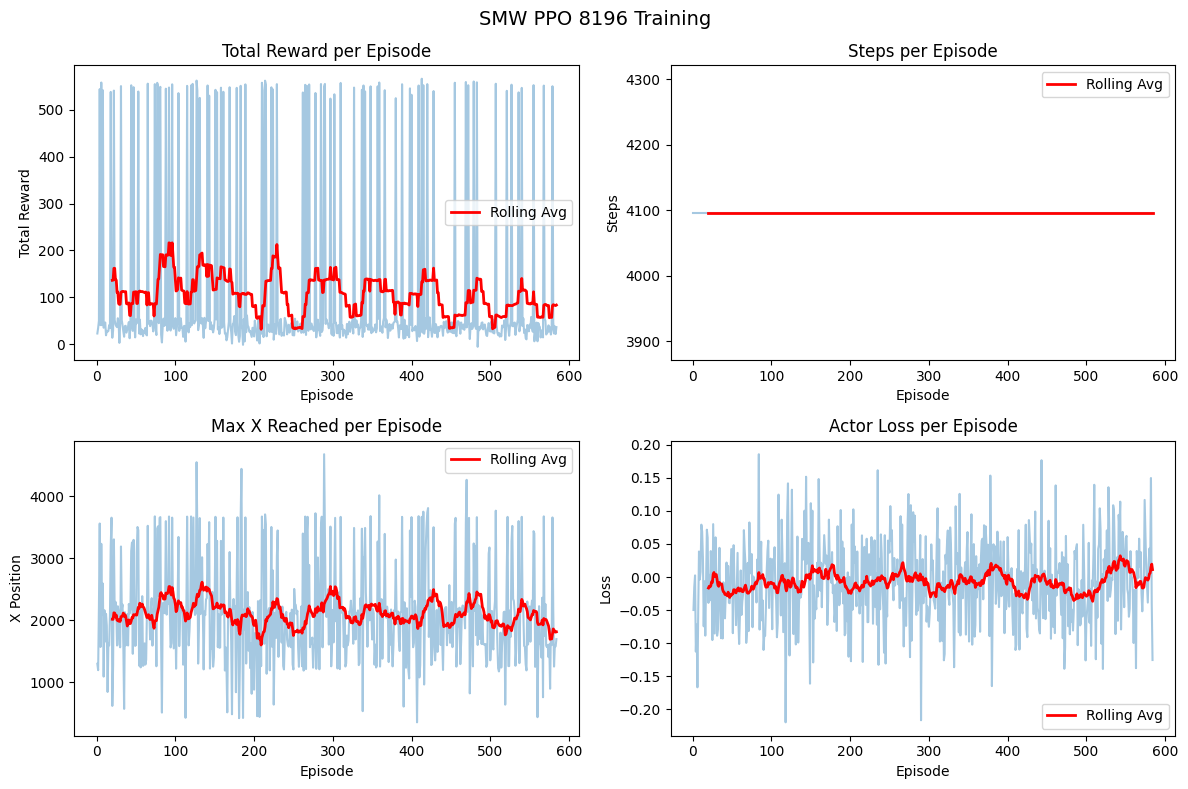

In [53]:
num_eps = len(total_rewards)
eps = range(1, num_eps + 1)
window = 20
rolling_eps = range(window, num_eps + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('SMW PPO 8196 Training', fontsize=14)

axes[0, 0].plot(eps, total_rewards, alpha=0.4)
rolling_avg = np.convolve(total_rewards, np.ones(window)/window, mode='valid')
axes[0, 0].plot(rolling_eps, rolling_avg, color='red', linewidth=2, label='Rolling Avg')
axes[0, 0].set_title('Total Reward per Episode')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].legend()

axes[0, 1].plot(eps, steps_per_ep, alpha=0.4)
rolling_steps = np.convolve(steps_per_ep, np.ones(window)/window, mode='valid')
axes[0, 1].plot(rolling_eps, rolling_steps, color='red', linewidth=2, label='Rolling Avg')
axes[0, 1].set_title('Steps per Episode')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Steps')
axes[0, 1].legend()

axes[1, 0].plot(eps, max_x_per_ep, alpha=0.4)
rolling_x = np.convolve(max_x_per_ep, np.ones(window)/window, mode='valid')
axes[1, 0].plot(rolling_eps, rolling_x, color='red', linewidth=2, label='Rolling Avg')
axes[1, 0].set_title('Max X Reached per Episode')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('X Position')
axes[1, 0].legend()

axes[1, 1].plot(eps, actor_losses, alpha=0.4)
rolling_loss = np.convolve(actor_losses, np.ones(window)/window, mode='valid')
axes[1, 1].plot(rolling_eps, rolling_loss, color='red', linewidth=2, label='Rolling Avg')
axes[1, 1].set_title('Actor Loss per Episode')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('Graphs/First8196_results.png')
plt.show()

In [13]:
# test a bunch of addresses around where x should be
import stable_retro

env = stable_retro.make(game='SuperMarioWorld-Snes-v0', render_mode='human')
env.reset()

for _ in range(100):
    action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]  # hold right
    env.step(action)

ram = env.get_ram()
# print addresses in the range we care about
for addr in [0x00D1, 0x00D3, 0x0086, 0x00D4, 0x00B6, 0x00B8]:
    print(f"0x{addr:04X}: {ram[addr]}")
    print(0x7E0000 + 0x00D1)  # x
    print(0x7E0000 + 0x00D4)  # screen  

env.close()

RuntimeError: Cannot create multiple emulator instances per process, make sure to call env.close() on each environment before creating a new one